# A/B Testing Simulation — SisaBisa

Fokus analisis:

> Menguji apakah rekomendasi resep berbasis prioritas bahan cepat kedaluwarsa lebih efektif dibanding rekomendasi resep biasa.

Karena aplikasi belum memiliki data user production, analisis ini menggunakan **simulasi data perilaku pengguna**. Simulasi ini tetap relevan untuk menunjukkan konsep A/B testing, perumusan hipotesis, perhitungan conversion rate, dan pengujian statistik.

In [ ]:
# Import library
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

# Latar Belakang Masalah

SisaBisa memiliki fitur rekomendasi resep untuk membantu pengguna memanfaatkan bahan makanan yang tersedia di rumah. Salah satu tujuan utama fitur ini adalah mengurangi potensi **food waste**, terutama pada bahan yang memiliki umur simpan pendek.

Dalam eksperimen ini, terdapat dua versi rekomendasi:

| Grup | Deskripsi |
|---|---|
| **Control (A)** | Rekomendasi resep berdasarkan popularitas bahan/resep umum |
| **Treatment (B)** | Rekomendasi resep berdasarkan prioritas bahan yang cepat kedaluwarsa |

Metrik utama yang digunakan adalah **cook rate**, yaitu proporsi pengguna yang memilih atau memasak resep setelah menerima rekomendasi.

# Perumusan Hipotesis

Karena metrik yang diuji berbentuk proporsi, yaitu user memasak resep (`1`) atau tidak memasak resep (`0`), maka uji statistik yang digunakan adalah **Two-Proportion Z-Test**.

Hipotesis:

- **H0 (Null Hypothesis):** Tidak ada perbedaan cook rate antara rekomendasi biasa dan rekomendasi berbasis bahan cepat kedaluwarsa.
- **H1 (Alternative Hypothesis):** Cook rate pada rekomendasi berbasis bahan cepat kedaluwarsa lebih tinggi dibanding rekomendasi biasa.

Dengan kata lain:

- H0: p_control = p_treatment
- H1: p_treatment > p_control

# Menghitung Kebutuhan Sampel

Diasumsikan bahwa:

- Cook rate baseline pada grup Control = 28%
- Target cook rate pada grup Treatment = 36%
- Significance level (alpha) = 0.05
- Power = 80%

Perhitungan dilakukan menggunakan pendekatan sample size untuk dua proporsi.

In [ ]:
def estimate_sample_size_proportions(p1, p2, alpha=0.05, beta=0.20, two_sided=False):
    """
    Menghitung jumlah sampel minimum per grup untuk membandingkan dua proporsi.

    Parameters:
    - p1: proporsi baseline/control
    - p2: proporsi target/treatment
    - alpha: tingkat signifikansi
    - beta: probability of Type II error; power = 1 - beta
    - two_sided: True jika uji dua arah, False jika uji satu arah

    Returns:
    - jumlah sampel minimum per grup
    """
    z_alpha = norm.ppf(1 - alpha / 2) if two_sided else norm.ppf(1 - alpha)
    z_beta = norm.ppf(1 - beta)

    pooled_p = (p1 + p2) / 2

    numerator = (
        z_alpha * np.sqrt(2 * pooled_p * (1 - pooled_p))
        + z_beta * np.sqrt(p1 * (1 - p1) + p2 * (1 - p2))
    ) ** 2

    denominator = (p2 - p1) ** 2

    return math.ceil(numerator / denominator)

baseline_rate = 0.28
target_rate = 0.36

sample_size_per_group = estimate_sample_size_proportions(
    baseline_rate,
    target_rate,
    alpha=0.05,
    beta=0.20,
    two_sided=False
)

sample_size_per_group

420

## Simulasi Data Pengguna

Data Simulasi

- Jumlah user Control = hasil sample size per grup
- Jumlah user Treatment = hasil sample size per grup
- Grup Control memiliki peluang cook rate sekitar 28%
- Grup Treatment memiliki peluang cook rate sekitar 36%

Kolom dataset simulasi:
- `user_id`
- `group`
- `recommended_strategy`
- `cooked_recipe`


In [ ]:
n_control = sample_size_per_group
n_treatment = sample_size_per_group

control_cooked = np.random.binomial(
    n=1,
    p=baseline_rate,
    size=n_control
)

treatment_cooked = np.random.binomial(
    n=1,
    p=target_rate,
    size=n_treatment
)

df_ab = pd.DataFrame({
    "user_id": range(1, n_control + n_treatment + 1),
    "group": ["Control"] * n_control + ["Treatment"] * n_treatment,
    "recommended_strategy": (
        ["Rekomendasi resep populer"] * n_control
        + ["Rekomendasi bahan cepat kedaluwarsa"] * n_treatment
    ),
    "cooked_recipe": np.concatenate([control_cooked, treatment_cooked])
})

df_ab.head()

,user_id,group,recommended_strategy,cooked_recipe
0,1,Control,Rekomendasi resep populer,0
1,2,Control,Rekomendasi resep populer,1
2,3,Control,Rekomendasi resep populer,1
3,4,Control,Rekomendasi resep populer,0
4,5,Control,Rekomendasi resep populer,0


## Conversion Rate / Cook Rate


> cook rate = jumlah user yang memasak resep / total user dalam grup

In [ ]:
summary = (
    df_ab
    .groupby("group")
    .agg(
        total_user=("user_id", "count"),
        total_cooked=("cooked_recipe", "sum"),
        cook_rate=("cooked_recipe", "mean")
    )
    .reset_index()
)

summary["cook_rate_percent"] = (summary["cook_rate"] * 100).round(2)
summary

,group,total_user,total_cooked,cook_rate,cook_rate_percent
0,Control,420,118,0.280952,28.10
1,Treatment,420,141,0.335714,33.57


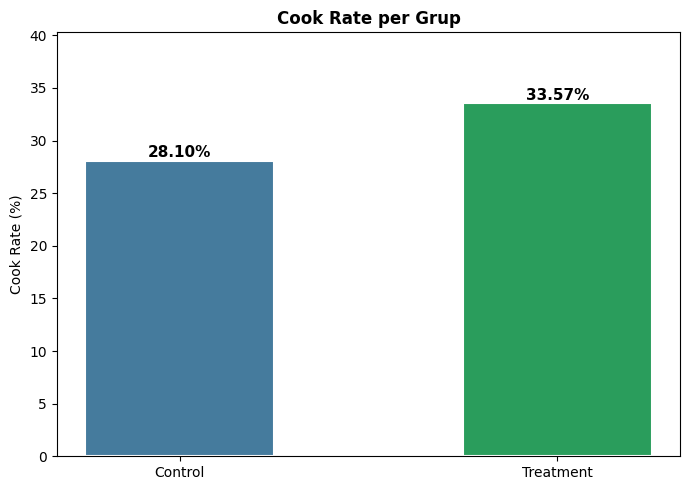

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

groups     = ['Control', 'Treatment']
cook_rates = [p_control * 100, p_treatment * 100]
colors     = ['#457B9D', '#2A9D5C']

bars = ax.bar(groups, cook_rates, color=colors, edgecolor='white',
              linewidth=1.5, width=0.5)

for bar, val in zip(bars, cook_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.2f}%', ha='center', fontsize=11, fontweight='bold')

ax.set_title('Cook Rate per Grup', fontweight='bold')
ax.set_ylabel('Cook Rate (%)')
ax.set_ylim(0, max(cook_rates) * 1.2)
plt.tight_layout()
plt.show()

Berdasarkan visualisasi di atas, grup Treatment yang menerima
rekomendasi resep berbasis bahan cepat kedaluwarsa memiliki cook rate
33.57% — lebih tinggi dibanding grup Control yang menerima
rekomendasi resep populer biasa dengan cook rate 28.10%.

Sekilas, perbedaan ini terlihat signifikan. Namun, perbedaan yang
tampak secara visual belum cukup kuat untuk dijadikan dasar kesimpulan
yang valid. Kita perlu menguji apakah perbedaan tersebut benar-benar
signifikan secara statistik atau hanya terjadi secara kebetulan —
inilah tujuan dari Two-Proportion Z-Test pada langkah berikutnya.

## Two-Proportion Z-Test

Karena metrik `cooked_recipe` berbentuk binary 0/1, maka uji yang digunakan adalah **two-proportion z-test**.

Rumus umum:
$$
z = \frac{\hat{p}_{treatment} - \hat{p}_{control}}
{\sqrt{\hat{p}(1-\hat{p})\left(\frac{1}{n_{control}} + \frac{1}{n_{treatment}}\right)}}
$$

Keterangan:

- p_control = cook rate Control
- p_treatment = cook rate Treatment
- p = pooled proportion
- n1 = jumlah user Control
- n2 = jumlah user Treatment

In [ ]:
def two_proportion_z_test(success_control, n_control, success_treatment, n_treatment):
    """
    Melakukan one-tailed two-proportion z-test.

    H0: p_control = p_treatment
    H1: p_treatment > p_control
    """
    p_control = success_control / n_control
    p_treatment = success_treatment / n_treatment

    pooled_p = (success_control + success_treatment) / (n_control + n_treatment)

    standard_error = np.sqrt(
        pooled_p * (1 - pooled_p) * (1 / n_control + 1 / n_treatment)
    )

    z_stat = (p_treatment - p_control) / standard_error

    # one-tailed p-value: treatment lebih besar dari control
    p_value = 1 - norm.cdf(z_stat)

    return z_stat, p_value, p_control, p_treatment

success_control = summary.loc[summary["group"] == "Control", "total_cooked"].values[0]
user_control = summary.loc[summary["group"] == "Control", "total_user"].values[0]

success_treatment = summary.loc[summary["group"] == "Treatment", "total_cooked"].values[0]
user_treatment = summary.loc[summary["group"] == "Treatment", "total_user"].values[0]

z_stat, p_value, p_control, p_treatment = two_proportion_z_test(
    success_control,
    user_control,
    success_treatment,
    user_treatment
)

print(f"Cook Rate Control   : {p_control:.4f} ({p_control*100:.2f}%)")
print(f"Cook Rate Treatment : {p_treatment:.4f} ({p_treatment*100:.2f}%)")
print(f"Z-statistic         : {z_stat:.4f}")
print(f"P-value             : {p_value:.6f}")

Cook Rate Control   : 0.2810 (28.10%)
Cook Rate Treatment : 0.3357 (33.57%)
Z-statistic         : 1.7184
P-value             : 0.042860


## Keputusan Uji Hipotesis

Kriteria keputusan:

- Jika p-value < 0.05 → Tolak H0
- Jika p-value ≥ 0.05 → Gagal menolak H0

In [ ]:
alpha = 0.05

if p_value < alpha:
    conclusion = "Tolak H0"
    interpretation = (
        "Terdapat bukti statistik bahwa rekomendasi berbasis bahan cepat kedaluwarsa "
        "memiliki cook rate yang lebih tinggi dibanding rekomendasi resep populer biasa."
    )
else:
    conclusion = "Gagal menolak H0"
    interpretation = (
        "Belum terdapat cukup bukti statistik bahwa rekomendasi berbasis bahan cepat kedaluwarsa "
        "lebih efektif dibanding rekomendasi resep populer biasa."
    )

print("Keputusan:", conclusion)
print("Interpretasi:", interpretation)

Keputusan: Tolak H0
Interpretasi: Terdapat bukti statistik bahwa rekomendasi berbasis bahan cepat kedaluwarsa memiliki cook rate yang lebih tinggi dibanding rekomendasi resep populer biasa.


## Analisis Dampak Bisnis

Jika Treatment terbukti lebih baik, maka rekomendasi berbasis bahan cepat kedaluwarsa dapat menjadi pendekatan yang lebih efektif untuk fitur SisaBisa.Sehingga dampak yang diharapkan:

1. Pengguna lebih terdorong memasak bahan yang harus segera digunakan.
2. Risiko bahan terbuang dapat berkurang.
3. Rekomendasi resep menjadi lebih relevan dengan kondisi stok pengguna.
4. Fitur prioritas masak dapat menjadi nilai utama aplikasi SisaBisa.

In [ ]:
lift = (p_treatment - p_control) / p_control * 100
absolute_diff = (p_treatment - p_control) * 100

print(f"Absolute Difference : {absolute_diff:.2f} percentage points")
print(f"Relative Lift       : {lift:.2f}%")

Absolute Difference : 5.48 percentage points
Relative Lift       : 19.49%


## Kesimpulan

Berdasarkan simulasi A/B testing, grup Treatment yang menerima rekomendasi resep berdasarkan bahan cepat kedaluwarsa memiliki cook rate lebih tinggi dibanding grup Control yang menerima rekomendasi resep populer biasa.

Hasil uji menunjukkan p-value = 0.0429 < 0.05, sehingga H0 ditolak.
Rekomendasi berbasis bahan cepat kedaluwarsa terbukti secara statistik
memiliki cook rate lebih tinggi (33.57%) dibanding rekomendasi populer biasa (28.10%),dengan relative lift sebesar 19.49%. Artinya, strategi rekomendasi berbasis prioritas bahan cepat kedaluwarsa berpotensi lebih efektif untuk meningkatkan tindakan pengguna dalam memilih atau memasak resep.

Hasil ini mendukung pengembangan fitur SisaBisa seperti:

- **Kulkas Virtual** untuk memantau stok bahan,
- **Prioritas Masak** berdasarkan umur simpan bahan,
- **Rekomendasi Resep** berdasarkan bahan yang perlu segera digunakan.